# Lending Club EDA

This notebook runs exploratory data analysis on the Kaggle Lending Club CSV downloaded into `data/loan.csv`.

The raw file is large, so the notebook scans the full dataset in chunks for target counts, missingness, and grouped default rates. It uses a sample for detailed numeric summaries and plots.

In [17]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.loan_default_risk.data import (
    LENDINGCLUB_MODEL_FEATURES,
    LENDINGCLUB_DEFAULT_STATUSES,
    LENDINGCLUB_NON_DEFAULT_STATUSES,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)

CSV_PATH = ROOT / "data" / "loan.csv"
OUT_DIR = ROOT / "outputs" / "eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH, CSV_PATH.exists(), OUT_DIR

(WindowsPath('c:/Users/khais/Desktop/Loan_risk_detectin/data/loan.csv'),
 True,
 WindowsPath('c:/Users/khais/Desktop/Loan_risk_detectin/outputs/eda'))

## Quick File Check

In [18]:
if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

file_size_gb = CSV_PATH.stat().st_size / 1024 / 1024 / 1024
header = pd.read_csv(CSV_PATH, nrows=0)
print(f"CSV path: {CSV_PATH}")
print(f"File size: {file_size_gb:.2f} GB")
print(f"Raw columns: {len(header.columns):,}")
header.columns.tolist()

CSV path: c:\Users\khais\Desktop\Loan_risk_detectin\data\loan.csv
File size: 1.11 GB
Raw columns: 145


['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_

## Preview

In [19]:
preview_cols = ["loan_status", *[c for c in LENDINGCLUB_MODEL_FEATURES if c in header.columns][:12]]
pd.read_csv(CSV_PATH, usecols=preview_cols, nrows=5)

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose
0,2500,2500,36 months,13.56,84.92,C,C1,10+ years,RENT,55000,Not Verified,Current,debt_consolidation
1,30000,30000,60 months,18.94,777.23,D,D2,10+ years,MORTGAGE,90000,Source Verified,Current,debt_consolidation
2,5000,5000,36 months,17.97,180.69,D,D1,6 years,MORTGAGE,59280,Source Verified,Current,debt_consolidation
3,4000,4000,36 months,18.94,146.51,D,D2,10+ years,MORTGAGE,92000,Source Verified,Current,debt_consolidation
4,30000,30000,60 months,16.14,731.78,C,C4,10+ years,MORTGAGE,57250,Not Verified,Current,debt_consolidation


## Full Dataset Chunk Scan

This scans the complete CSV without loading all rows into memory.

In [20]:
TARGET = "loan_status"
usecols = [TARGET, *LENDINGCLUB_MODEL_FEATURES]
existing_usecols = [c for c in usecols if c in header.columns]
group_cols = ["grade", "term", "purpose", "home_ownership", "verification_status", "application_type"]

status_counts = pd.Series(dtype="int64")
missing_counts = pd.Series(0, index=existing_usecols, dtype="int64")
group_aggs = {col: {} for col in group_cols if col in existing_usecols}
total_rows = 0

sample_parts = []
rng = np.random.default_rng(42)

for chunk in pd.read_csv(CSV_PATH, usecols=existing_usecols, chunksize=200_000, low_memory=True):
    total_rows += len(chunk)
    status_counts = status_counts.add(chunk[TARGET].value_counts(dropna=False), fill_value=0)
    missing_counts = missing_counts.add(chunk.isna().sum(), fill_value=0)

    cleaned_target = chunk[TARGET].astype("string").str.strip().str.lower()
    y = pd.Series(np.nan, index=chunk.index, dtype="float")
    y.loc[cleaned_target.isin(LENDINGCLUB_DEFAULT_STATUSES)] = 1.0
    y.loc[cleaned_target.isin(LENDINGCLUB_NON_DEFAULT_STATUSES)] = 0.0
    valid = y.notna()

    for col in group_aggs:
        grouped = pd.DataFrame({col: chunk.loc[valid, col], "default": y.loc[valid]}).dropna(subset=[col])
        if grouped.empty:
            continue
        part = grouped.groupby(col)["default"].agg(["count", "sum"])
        for key, row in part.iterrows():
            current = group_aggs[col].setdefault(str(key), [0, 0.0])
            current[0] += int(row["count"])
            current[1] += float(row["sum"])

    sample_n = min(20_000, len(chunk))
    if sample_n:
        sampled = chunk.iloc[rng.choice(len(chunk), sample_n, replace=False)].copy()
        sample_parts.append(sampled)

status_counts = status_counts.astype(int).sort_values(ascending=False)
sample = pd.concat(sample_parts, ignore_index=True)
if len(sample) > 250_000:
    sample = sample.sample(n=250_000, random_state=42).reset_index(drop=True)

print(f"Rows scanned: {total_rows:,}")
print(f"Sample rows retained: {len(sample):,}")

Rows scanned: 2,260,668
Sample rows retained: 240,000


## Target Distribution

In [21]:
default_rows = sum(
    count for label, count in status_counts.items()
    if str(label).strip().lower() in LENDINGCLUB_DEFAULT_STATUSES
)
non_default_rows = sum(
    count for label, count in status_counts.items()
    if str(label).strip().lower() in LENDINGCLUB_NON_DEFAULT_STATUSES
)
known_rows = int(default_rows + non_default_rows)
default_rate = default_rows / known_rows

print(f"Known binary target rows: {known_rows:,}")
print(f"Default rows: {int(default_rows):,}")
print(f"Non-default rows: {int(non_default_rows):,}")
print(f"Default rate: {default_rate:.2%}")

status_counts.to_csv(OUT_DIR / "loan_status_counts.csv", header=["count"])
status_counts.to_frame("count")

Known binary target rows: 2,260,668
Default rows: 284,344
Non-default rows: 1,976,324
Default rate: 12.58%


,count
loan_status,
Fully Paid,1041952
Current,919695
Charged Off,261655
Late (31-120 days),21897
In Grace Period,8952
Late (16-30 days),3737
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,31


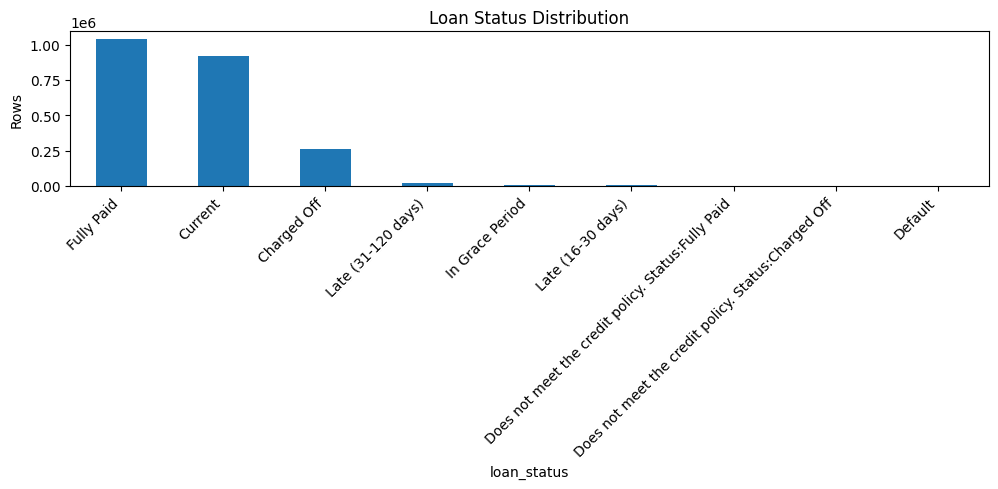

In [22]:
plt.figure(figsize=(10, 5))
status_counts.plot(kind="bar")
plt.title("Loan Status Distribution")
plt.ylabel("Rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "loan_status_distribution.png", dpi=150)
plt.show()

## Missingness

In [23]:
missing_df = pd.DataFrame({
    "column": missing_counts.index,
    "missing_count": missing_counts.astype(int).values,
    "missing_pct": (missing_counts / total_rows * 100).round(2).values,
}).sort_values("missing_pct", ascending=False)

missing_df.to_csv(OUT_DIR / "missingness_selected_features.csv", index=False)
missing_df.head(20)

,column,missing_count,missing_pct
26,mths_since_last_record,1901512,84.11
25,mths_since_last_delinq,1158502,51.25
14,emp_length,146907,6.50
7,bc_util,76071,3.36
6,bc_open_to_buy,74935,3.31
37,tot_cur_bal,70276,3.11
5,avg_cur_bal,70346,3.11
39,total_rev_hi_lim,70276,3.11
36,tot_coll_amt,70276,3.11
24,mort_acc,50030,2.21


## Prepare Sample for Detailed EDA

In [24]:
for col in ["int_rate", "revol_util"]:
    if col in sample.columns:
        sample[col] = pd.to_numeric(sample[col].astype("string").str.rstrip("%"), errors="coerce")

cleaned_sample_target = sample[TARGET].astype("string").str.strip().str.lower()
sample["default_flag"] = np.nan
sample.loc[cleaned_sample_target.isin(LENDINGCLUB_DEFAULT_STATUSES), "default_flag"] = 1.0
sample.loc[cleaned_sample_target.isin(LENDINGCLUB_NON_DEFAULT_STATUSES), "default_flag"] = 0.0
valid_sample = sample[sample["default_flag"].notna()].copy()

valid_sample.shape

(240000, 42)

## Numeric Summary

In [25]:
numeric_cols = [
    c for c in valid_sample.columns
    if c not in [TARGET, "default_flag"] and pd.api.types.is_numeric_dtype(valid_sample[c])
]
numeric_summary = valid_sample[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75]).T.round(3)
numeric_summary.to_csv(OUT_DIR / "numeric_summary_sample.csv")
numeric_summary

,count,mean,std,min,25%,50%,75%,max
loan_amnt,240000.0,15042.772188,9221.062149,700.0,8000.0,12800.0,20000.0,40000.0
funded_amnt,240000.0,15038.093229,9219.696991,700.0,8000.0,12800.0,20000.0,40000.0
int_rate,240000.0,13.088645,4.866559,5.31,9.44,12.62,15.99,30.99
installment,240000.0,445.449622,267.779132,19.87,251.34,377.09,593.32,1714.54
annual_inc,240000.0,78023.911798,74788.010111,0.0,46000.0,65000.0,93000.0,9000000.0
dti,239796.0,18.811684,13.906093,-1.0,11.85,17.82,24.48,999.0
delinq_2yrs,239998.0,0.301857,0.859368,0.0,0.0,0.0,0.0,42.0
inq_last_6mths,239998.0,0.571442,0.875687,0.0,0.0,0.0,1.0,15.0
mths_since_last_delinq,116150.0,34.659346,21.873949,0.0,16.0,32.0,50.0,162.0
mths_since_last_record,37917.0,72.87172,26.37077,0.0,55.0,75.0,93.0,124.0


## Categorical Top Values

In [26]:
cat_cols = [c for c in LENDINGCLUB_MODEL_FEATURES if c in valid_sample.columns and c not in numeric_cols]
cat_rows = []
for col in cat_cols:
    vc = valid_sample[col].value_counts(dropna=False).head(10)
    for value, count in vc.items():
        cat_rows.append({"column": col, "value": value, "count_in_sample": int(count)})

categorical_top = pd.DataFrame(cat_rows)
categorical_top.to_csv(OUT_DIR / "categorical_top_values_sample.csv", index=False)
categorical_top

,column,value,count_in_sample
0,term,36 months,170781
1,term,60 months,69219
2,grade,B,70487
3,grade,C,68914
4,grade,A,46355
5,grade,D,34552
6,grade,E,14005
7,grade,F,4374
8,grade,G,1313
9,sub_grade,C1,15370


## Default Rate by Groups

In [27]:
rate_tables = {}
for col, values in group_aggs.items():
    rows = []
    for value, (count, defaults) in values.items():
        rows.append({
            "value": value,
            "count": count,
            "defaults": int(defaults),
            "default_rate_pct": round(defaults / count * 100, 3) if count else 0,
        })
    table = pd.DataFrame(rows).sort_values(["default_rate_pct", "count"], ascending=False)
    table.to_csv(OUT_DIR / f"default_rate_by_{col}.csv", index=False)
    rate_tables[col] = table

rate_tables["grade"]

,value,count,defaults,default_rate_pct
6,G,12168,4810,39.530
5,F,41800,15076,36.067
4,E,135639,37752,27.833
3,D,324424,64631,19.922
2,C,650053,91059,14.008
1,B,663557,55926,8.428
0,A,433027,15090,3.485


In [28]:
for col in ["term", "purpose", "home_ownership", "verification_status", "application_type"]:
    display(col, rate_tables[col].head(15))

'term'

,value,count,defaults,default_rate_pct
1,60 months,650914,111672,17.156
0,36 months,1609754,172672,10.727


'purpose'

,value,count,defaults,default_rate_pct
13,educational,424,88,20.755
10,small_business,24689,4892,19.814
9,renewable_energy,1445,232,16.055
7,moving,15403,2353,15.276
2,debt_consolidation,1277877,173985,13.615
6,medical,27488,3632,13.213
8,other,139440,17662,12.666
12,wedding,2355,292,12.399
4,house,14136,1735,12.274
11,vacation,15525,1861,11.987


'home_ownership'

,value,count,defaults,default_rate_pct
5,OTHER,182,38,20.879
4,NONE,54,8,14.815
3,RENT,894929,131016,14.640
2,OWN,253057,31801,12.567
1,MORTGAGE,1111450,121416,10.924
0,ANY,996,65,6.526


'verification_status'

,value,count,defaults,default_rate_pct
2,Verified,629631,104726,16.633
1,Source Verified,886231,115680,13.053
0,Not Verified,744806,63938,8.585


'application_type'

,value,count,defaults,default_rate_pct
0,Individual,2139958,276427,12.917
1,Joint App,120710,7917,6.559


## Plots

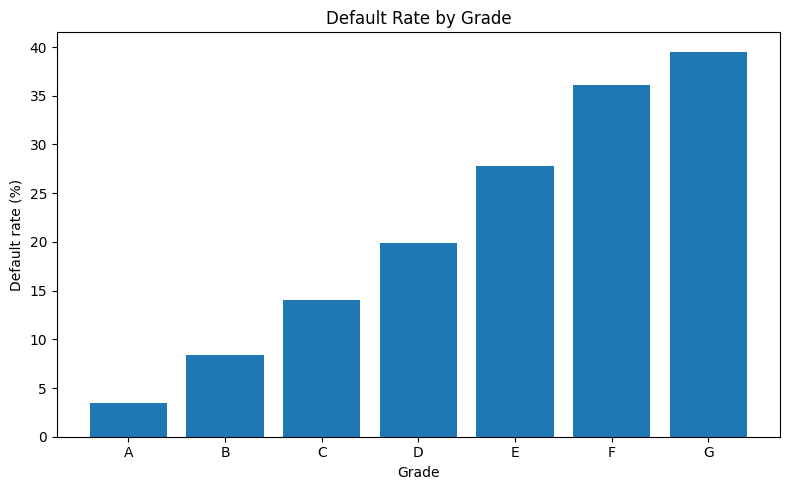

In [29]:
grade_table = rate_tables["grade"].sort_values("value")

plt.figure(figsize=(8, 5))
plt.bar(grade_table["value"], grade_table["default_rate_pct"])
plt.title("Default Rate by Grade")
plt.xlabel("Grade")
plt.ylabel("Default rate (%)")
plt.tight_layout()
plt.savefig(OUT_DIR / "default_rate_by_grade.png", dpi=150)
plt.show()

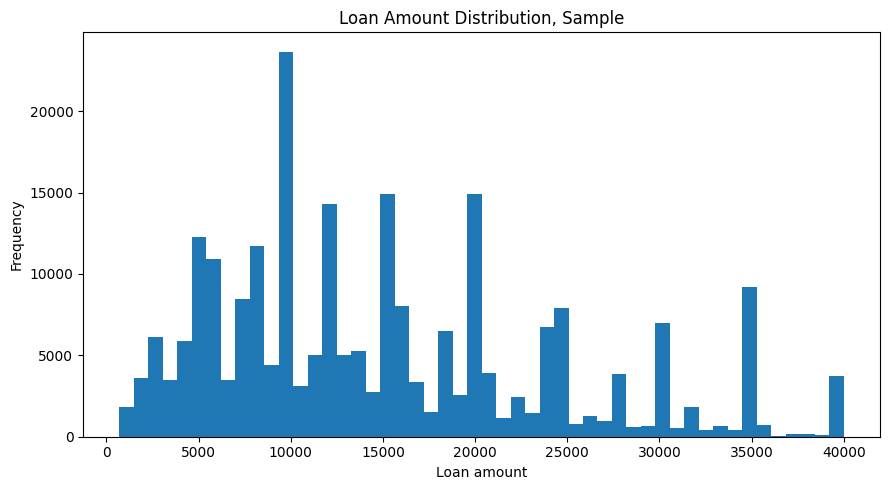

In [30]:
plt.figure(figsize=(9, 5))
valid_sample["loan_amnt"].dropna().plot(kind="hist", bins=50)
plt.title("Loan Amount Distribution, Sample")
plt.xlabel("Loan amount")
plt.tight_layout()
plt.savefig(OUT_DIR / "loan_amount_distribution_sample.png", dpi=150)
plt.show()

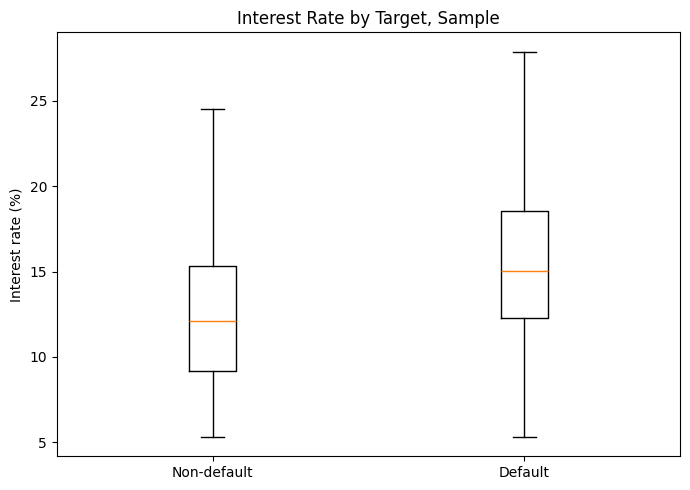

In [31]:
box_data = [
    valid_sample.loc[valid_sample["default_flag"] == 0, "int_rate"].dropna(),
    valid_sample.loc[valid_sample["default_flag"] == 1, "int_rate"].dropna(),
]

plt.figure(figsize=(7, 5))
plt.boxplot(box_data, tick_labels=["Non-default", "Default"], showfliers=False)
plt.title("Interest Rate by Target, Sample")
plt.ylabel("Interest rate (%)")
plt.tight_layout()
plt.savefig(OUT_DIR / "interest_rate_by_target_sample.png", dpi=150)
plt.show()

## Save Markdown Summary

In [32]:
lines = []
lines.append("# Lending Club EDA")
lines.append("")
lines.append(f"Source CSV: `{CSV_PATH}`")
lines.append(f"File size: {file_size_gb:.2f} GB")
lines.append(f"Rows scanned: {total_rows:,}")
lines.append(f"Columns in raw CSV: {len(header.columns):,}")
lines.append(f"Selected model columns scanned: {len(existing_usecols):,}")
lines.append(f"Known binary target rows: {known_rows:,}")
lines.append(f"Default rows: {int(default_rows):,}")
lines.append(f"Non-default rows: {int(non_default_rows):,}")
lines.append(f"Overall default rate among mapped statuses: {default_rate:.2%}")
lines.append("")
lines.append("## Loan Status Counts")
lines.append(status_counts.to_frame("count").to_markdown())
lines.append("")
lines.append("## Highest Missingness Among Selected Features")
lines.append(missing_df.head(15).to_markdown(index=False))
lines.append("")
lines.append("## Numeric Summary, Sample")
lines.append(numeric_summary.head(20).to_markdown())
lines.append("")
for col in group_cols:
    if col in rate_tables:
        lines.append(f"## Default Rate by {col}")
        lines.append(rate_tables[col].head(15).to_markdown(index=False))
        lines.append("")
lines.append("## Generated Files")
for file in sorted(OUT_DIR.iterdir()):
    lines.append(f"- `{file}`")

report_path = OUT_DIR / "lendingclub_eda.md"
report_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Saved report: {report_path}")

Saved report: c:\Users\khais\Desktop\Loan_risk_detectin\outputs\eda\lendingclub_eda.md
